# **Musae** — MUon Scattering and Absorption tomography simulation infrastructurE
# Copyright (C) 2026 Musae developers
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# ML-EM Muon Scattering Tomography Reconstruction
# Based on L. Schultz et al., "ML/EM Reconstruction Algorithm for
# Cosmic Ray Muon Tomography", IEEE TIP.

In [59]:
import numpy as np
import pandas as pd
import scipy as scp
from scipy.sparse import coo_matrix, csr_matrix
from scipy.linalg import inv
import numba
from matplotlib import pyplot as plt
import os
import json
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [60]:
# ============================================================
# User-Defined Parameters
# ============================================================

# --- Numeric options ---
FLOAT = np.float64
INT = np.int32
REL_GEOM_TOL = 1e-6

# --- Reconstruction volume (AABB) ---
# Units: cm  (positions converted from mm → cm internally)
X_MIN, X_MAX = -30.0, 30.0      # cm
Y_MIN, Y_MAX = -30.0, 30.0      # cm
Z_MIN, Z_MAX = -30.0, 30.0      # cm
N_X = 10   # number of voxels along x
N_Y = 10   # number of voxels along y
N_Z = 10   # number of voxels along z

# --- Input data ---
INPUT_CSV = "../Musae-main/data/Recon_output/ConcreteWall/scatter/Scatter_cube_5p4e9.csv"
# INPUT_CSV = "test_data_perfect.csv"
# Number of events to load (None = load all, int = load first N rows)
# N_EVENTS = 100000
N_EVENTS = None

# --- Physics parameters ---
P0 = 1000.0          # Nominal muon momentum (MeV/c)
LAMBDA_INIT = 1.0    # Initial scattering density λ (mrad²/cm)

# --- Detector error matrix E (4×4) ---
E_MATRIX = np.zeros((4, 4), dtype=FLOAT)

# --- Iteration parameters ---
METHOD = 'median'       # M-step method: 'mean' (Eq.38) or 'median' (Eq.38.2)
N_ITER = 50          # Max number of iterations
TOL = 1e-4            # Relative change tolerance for early stopping
USE_TOL_STOP = False  # If True, stop when ||λ_new - λ_old|| / ||λ_old|| < TOL

# --- Scattering angle pre-filter (Zhi Yu et al., 2020, Eq. 6-7) ---
# Events with 3D scattering angle below this threshold have unreliable
# PoCA points due to nearly-parallel incoming/outgoing rays.
# These events are redirected to straight-line path regardless of
# the POCA_HANDLING mode (except pure 'straightline' which ignores PoCA entirely).
MIN_SCATTER_MRAD = 0.8   # mrad

# --- PoCA handling for constrained events ---
# 'hybrid'      = PoCA path when unconstrained, straight-line when constrained
# 'discard'     = discard events with scatter < MIN_SCATTER_MRAD (pre-filter)
#                 and constrained PoCA; use PoCA for the rest
# 'straightline' = use straight-line path for ALL events (ignore PoCA entirely)
# NOTE: Use 'straightline' for perfect test data (generated with straight-line
#       forward model).  Use 'hybrid' or 'discard' for real Geant4 data.
POCA_HANDLING = 'discard'

# --- Output ---
OUTPUT_DIR = "output/ML_EM"
now = datetime.now()
npy_filename = f"Scatter_cube_5p4e9_{METHOD}_{POCA_HANDLING}_N{N_ITER}_{now.month:02d}-{now.day:02d}.npy"

In [61]:
# ============================================================
# Load Data
# ============================================================

print(f"Loading data from: {INPUT_CSV}")
if N_EVENTS is not None:
    print(f"  (loading first {N_EVENTS} events only — for quick testing)")
df = pd.read_csv(INPUT_CSV, nrows=N_EVENTS)
print(f"Loaded {len(df)} muon events.")
print(f"Columns: {list(df.columns)}")

# Convert positions from mm to cm (internal unit)
# The AnaScatter output has positions in mm
for col in ['x_in', 'y_in', 'z_in', 'x_out', 'y_out', 'z_out']:
    df[col] = df[col] / 10.0  # mm → cm

# Convert momentum from GeV/c to MeV/c for p_r² calculation
df['p_mom_MeV'] = df['p_mom'] * 1000.0  # GeV/c → MeV/c

# Compute direction vectors from theta/phi
# theta = angle from downward vertical (theta=0 = straight down)
# The standard spherical formula (sinθ·cosφ, sinθ·sinφ, cosθ) gives
# the direction TOWARD the muon source (upward).
# The muon's ACTUAL travel direction is the NEGATIVE of this:
#   d = (-sinθ·cosφ, -sinθ·sinφ, -cosθ)
df['ux_in'] = -np.sin(df['theta_in']) * np.cos(df['phi_in'])
df['uy_in'] = -np.sin(df['theta_in']) * np.sin(df['phi_in'])
df['uz_in'] = -np.cos(df['theta_in'])

df['ux_out'] = -np.sin(df['theta_out']) * np.cos(df['phi_out'])
df['uy_out'] = -np.sin(df['theta_out']) * np.sin(df['phi_out'])
df['uz_out'] = -np.cos(df['theta_out'])

# Normalize direction vectors (safety check)
for suffix in ['_in', '_out']:
    norm = np.sqrt(df[f'ux{suffix}']**2 + df[f'uy{suffix}']**2 + df[f'uz{suffix}']**2)
    df[f'ux{suffix}'] /= norm
    df[f'uy{suffix}'] /= norm
    df[f'uz{suffix}'] /= norm

print("\nDirection vector ranges:")
print(f"  d_in  z-component (cosθ_in):  [{df['uz_in'].min():.4f}, {df['uz_in'].max():.4f}]")
print(f"  d_out z-component (cosθ_out): [{df['uz_out'].min():.4f}, {df['uz_out'].max():.4f}]")
print(f"  p_mom range: [{df['p_mom_MeV'].min():.0f}, {df['p_mom_MeV'].max():.0f}] MeV/c")

Loading data from: ../Musae-main/data/Recon_output/ConcreteWall/scatter/Scatter_cube_5p4e9.csv
Loaded 8097938 muon events.
Columns: ['EvtID', 'theta_in', 'phi_in', 'x_in', 'y_in', 'z_in', 'theta_out', 'phi_out', 'x_out', 'y_out', 'z_out', 'p_mom']

Direction vector ranges:
  d_in  z-component (cosθ_in):  [-1.0000, -0.5000]
  d_out z-component (cosθ_out): [-1.0000, -0.5000]
  p_mom range: [57, 992318] MeV/c


In [62]:
# ============================================================
# Grid Setup
# ============================================================

# Voxel dimensions (cm)
dx = (X_MAX - X_MIN) / N_X
dy = (Y_MAX - Y_MIN) / N_Y
dz = (Z_MAX - Z_MIN) / N_Z

R_MIN = np.array([X_MIN, Y_MIN, Z_MIN], dtype=FLOAT)
R_MAX = np.array([X_MAX, Y_MAX, Z_MAX], dtype=FLOAT)
N_R = np.array([N_X, N_Y, N_Z], dtype=INT)
N_VOXELS = N_X * N_Y * N_Z
DU = np.array([dx, dy, dz], dtype=FLOAT)
ABS_GEOM_TOL = np.linalg.norm(DU) * REL_GEOM_TOL
# Filter events where scattering/displacement is unreasonably large
# (the small-angle model breaks down for large scattering)
MAX_SCATTER_ANGLE = np.pi / 2  # filter extreme events
MAX_DISPLACEMENT = 30.0        # cm — filter unphysical displacements

print(f"Grid: {N_X} × {N_Y} × {N_Z} = {N_VOXELS} voxels")
print(f"Voxel size: dx={dx:.2f}, dy={dy:.2f}, dz={dz:.2f} cm")
print(f"Volume: [{X_MIN}, {X_MAX}] × [{Y_MIN}, {Y_MAX}] × [{Z_MIN}, {Z_MAX}] cm")
print(f"ABS_GEOM_TOL: {ABS_GEOM_TOL:.2e}")


@numba.njit
def r_to_ijk(r):
    """Map 3D position r to voxel indices (i, j, k)."""
    ijk = ((r - R_MIN) / DU).astype(INT)
    return np.maximum(0, np.minimum(ijk, N_R - 1))


@numba.njit
def ijk_to_flat(ijk):
    """Convert (i, j, k) to flat voxel index."""
    i, j, k = ijk
    return i * N_Y * N_Z + j * N_Z + k


@numba.njit
def flat_to_ijk(idx):
    """Convert flat voxel index to (i, j, k)."""
    k = idx % N_Z
    j = (idx // N_Z) % N_Y
    i = idx // (N_Y * N_Z)
    return np.array([i, j, k], dtype=INT)

Grid: 10 × 10 × 10 = 1000 voxels
Voxel size: dx=6.00, dy=6.00, dz=6.00 cm
Volume: [-30.0, 30.0] × [-30.0, 30.0] × [-30.0, 30.0] cm
ABS_GEOM_TOL: 1.04e-05


In [63]:
# ============================================================
# Step 0: Ray-AABB Intersection
# ============================================================

@numba.njit
def ray_aabb_intersection(origin, direction):
    """
    Compute entry and exit parameters (t_enter, t_exit) for a ray
    intersecting an axis-aligned bounding box.

    The ray origin MUST be outside the AABB — detector positions are
    never inside the reconstruction volume.

    Parameters
    ----------
    origin : np.ndarray[3]
        Ray origin (detector hit position). Must be outside the AABB.
    direction : np.ndarray[3]
        Ray direction unit vector. For incoming ray, this is d_in (forward).
        For outgoing ray, pass -d_out to trace backward.

    Returns
    -------
    t_enter : float
        Parameter along ray where it first enters the AABB.
        Returns -1.0 if ray does not intersect or origin is inside AABB.
    t_exit : float
        Parameter along ray where it exits the AABB.
    """
    # Safety check: origin must NOT be inside the AABB
    inside = True
    for a in range(3):
        if origin[a] < R_MIN[a] or origin[a] > R_MAX[a]:
            inside = False
            break
    if inside:
        # Detector position inside reconstruction volume → error
        return -1.0, -1.0

    t_near = -np.inf
    t_far = np.inf

    for a in range(3):
        if np.abs(direction[a]) < 1e-12:
            # Ray is parallel to this axis
            if origin[a] < R_MIN[a] or origin[a] > R_MAX[a]:
                return -1.0, -1.0
            continue

        # Compute intersections with the two boundary planes
        t_low = (R_MIN[a] - origin[a]) / direction[a]
        t_high = (R_MAX[a] - origin[a]) / direction[a]

        if t_low > t_high:
            t_low, t_high = t_high, t_low

        t_near = max(t_near, t_low)
        t_far = min(t_far, t_high)

        if t_near > t_far:
            return -1.0, -1.0

    if t_far < 0.0:
        return -1.0, -1.0

    t_enter = max(t_near, 0.0)

    return t_enter, t_far


@numba.njit
def compute_entry_exit_points_all(events):
    """
    For all muon events, compute the entry and exit points
    of the incoming and outgoing rays through the reconstruction volume.

    Stores valid event indices so the caller can correctly align data.

    Returns
    -------
    p_in_vol : np.ndarray shape (M_valid, 3)
    p_out_vol : np.ndarray shape (M_valid, 3)
    valid_indices : np.ndarray shape (M_valid,)
        Original indices of valid events.
    valid_count : int
    """
    M = events.shape[0]
    # Pre-allocate for max possible valid events
    p_in_list = np.zeros((M, 3), dtype=FLOAT)
    p_out_list = np.zeros((M, 3), dtype=FLOAT)
    valid_idx_list = np.zeros(M, dtype=INT)
    valid_count = 0

    for i in range(M):
        p_in_det = np.array([events[i, 3], events[i, 4], events[i, 5]], dtype=FLOAT)
        p_out_det = np.array([events[i, 8], events[i, 9], events[i, 10]], dtype=FLOAT)
        d_in = np.array([events[i, 12], events[i, 13], events[i, 14]], dtype=FLOAT)
        d_out = np.array([events[i, 15], events[i, 16], events[i, 17]], dtype=FLOAT)

        # Incoming ray: trace forward along d_in
        t_enter_in, t_exit_in = ray_aabb_intersection(p_in_det, d_in)
        if t_enter_in < 0 or t_enter_in > t_exit_in:
            continue

        p_in_vol_point = p_in_det + t_enter_in * d_in

        # Outgoing ray: trace backward along -d_out
        d_out_rev = -d_out
        t_enter_rev, t_exit_rev = ray_aabb_intersection(p_out_det, d_out_rev)
        if t_enter_rev < 0:
            continue

        p_out_vol_point = p_out_det + t_enter_rev * d_out_rev

        # Store at correct position
        p_in_list[valid_count] = p_in_vol_point
        p_out_list[valid_count] = p_out_vol_point
        valid_idx_list[valid_count] = i
        valid_count += 1

    return (p_in_list[:valid_count], p_out_list[:valid_count],
            valid_idx_list[:valid_count], valid_count)


print("\n--- Step 0: Ray-AABB Intersection ---")

# Build event array for numba
event_cols = ['EvtID', 'theta_in', 'phi_in', 'x_in', 'y_in', 'z_in',
              'theta_out', 'phi_out', 'x_out', 'y_out', 'z_out',
              'p_mom_MeV', 'ux_in', 'uy_in', 'uz_in', 'ux_out', 'uy_out', 'uz_out']
events_np = df[event_cols].values.astype(FLOAT)

p_in_vol, p_out_vol, valid_indices, n_valid_p0 = \
    compute_entry_exit_points_all(events_np)

# Properly filter events array using valid indices
events_valid = events_np[valid_indices]
d_in_arr = events_valid[:, 12:15]
d_out_arr = events_valid[:, 15:18]
p_mom_arr = events_valid[:, 11]

M = n_valid_p0
print(f"Total events: {len(df)}, Valid (intersect volume): {M}, "
      f"Skipped: {len(df) - M}")


--- Step 0: Ray-AABB Intersection ---
Total events: 8097938, Valid (intersect volume): 7988988, Skipped: 108950


In [64]:
# ============================================================
# Step 1: Compute Observation Vector D_i
# ============================================================

print("\n--- Step 1: Observation Vector D_i ---")

# Extract angles from valid events
theta_in = events_valid[:, 1]
phi_in = events_valid[:, 2]
theta_out = events_valid[:, 6]
phi_out = events_valid[:, 7]

# Projected angles measured from the DOWNWARD vertical (-z).
#
# The muon travel direction is d = (-sinθ·cosφ, -sinθ·sinφ, -cosθ),
# where θ,φ describe the SOURCE direction (toward the sky).
#
# The projected angle in the x-z plane is:
#   θ_x = arctan(dx / |dz|) = arctan(-sinθ·cosφ / cosθ)
#       = -arctan(tanθ·cosφ)
#
# NOTE the minus sign — this is the angle from the downward vertical.
# A muon traveling in the +x direction has a POSITIVE projected angle.
theta_x_in = -np.arctan2(np.sin(theta_in) * np.cos(phi_in), np.cos(theta_in))
theta_y_in = -np.arctan2(np.sin(theta_in) * np.sin(phi_in), np.cos(theta_in))
theta_x_out = -np.arctan2(np.sin(theta_out) * np.cos(phi_out), np.cos(theta_out))
theta_y_out = -np.arctan2(np.sin(theta_out) * np.sin(phi_out), np.cos(theta_out))

# Scattering angles (Eq. 13) — in RADIANS
delta_theta_x = theta_x_out - theta_x_in
delta_theta_y = theta_y_out - theta_y_in

# 3D path length factor (Eq. 12)
L_xy = np.sqrt(1.0 + np.tan(theta_x_in)**2 + np.tan(theta_y_in)**2)

# Height H = |z_out_vol - z_in_vol| (use volume entry/exit points)
H_arr = np.abs(p_out_vol[:, 2] - p_in_vol[:, 2])

# Clip H to positive minimum to avoid degenerate rays
H_arr = np.maximum(H_arr, 1e-6)

# Unscattered projection position (Eq. 12)
x_p = p_in_vol[:, 0] + H_arr * np.tan(theta_x_in)
y_p = p_in_vol[:, 1] + H_arr * np.tan(theta_y_in)

# Displacement Δx, Δy (Eq. 14) with numerical stability
cos_tx_in = np.cos(theta_x_in)
cos_ty_in = np.cos(theta_y_in)
cos_dtx = np.cos(delta_theta_x)
cos_dty = np.cos(delta_theta_y)

# Clip near-zero cosines to prevent division overflow
EPS_COS = 1e-4
cos_dtx_safe = np.where(np.abs(cos_dtx) < EPS_COS,
                         np.sign(cos_dtx + 1e-30) * EPS_COS, cos_dtx)
cos_dty_safe = np.where(np.abs(cos_dty) < EPS_COS,
                         np.sign(cos_dty + 1e-30) * EPS_COS, cos_dty)

delta_x = ((p_out_vol[:, 0] - x_p) * cos_tx_in * L_xy
           * np.cos(delta_theta_x + theta_x_in) / cos_dtx_safe)
delta_y = ((p_out_vol[:, 1] - y_p) * cos_ty_in * L_xy
           * np.cos(delta_theta_y + theta_y_in) / cos_dty_safe)

# ================================================================
# CRITICAL UNIT CONVERSION — both angle AND displacement:
#
# The Schultz ML-EM algorithm defines λ in mrad²/cm (Eq. 3).
# This means the covariance matrix Σ = λ·W has mixed units:
#   Σ_00 = λ·W_00   →  mrad²           (W_00 = L [cm])
#   Σ_11 = λ·W_11   →  mrad²·cm²       (W_11 ~ L³, L·T² [cm³])
#
# For Dᵀ Σ⁻¹ D to be numerically consistent, D components MUST
# be expressed in units whose squares match Σ's diagonal:
#   D_0 (Δθ) must be in mrad       →  × 1000
#   D_1 (Δx) must be in mrad·cm    →  × 1000  (NOT cm!)
#
# Why: 0.06 cm = 60 mrad·cm (because 1 mrad = 0.001 dimensionless,
# so 1 mrad·cm = 0.001 cm).  Without this scaling, D_1² is 10⁻⁶
# times Σ_11, suppressing the displacement contribution to DᵀΣ⁻¹D.
# The algorithm loses z-axis localization (which comes from the
# T-dependent W elements that affect Σ_01 and Σ_11).
# ================================================================
MRAD_PER_RAD = 1000.0

delta_theta_x_mrad = delta_theta_x * MRAD_PER_RAD      # rad → mrad
delta_theta_y_mrad = delta_theta_y * MRAD_PER_RAD      # rad → mrad
delta_x_scaled      = delta_x * MRAD_PER_RAD            # cm → mrad·cm
delta_y_scaled      = delta_y * MRAD_PER_RAD            # cm → mrad·cm

# Data vector D_i shape: (M, 4)
#   D_i = [δθ_x (mrad), δθ_y (mrad), Δx (mrad·cm), Δy (mrad·cm)]
D_all = np.column_stack([delta_theta_x_mrad, delta_theta_y_mrad,
                          delta_x_scaled, delta_y_scaled])

# Momentum correction factor p_r² = (p₀/p)²  (Eq. 5)
pr2 = (P0 / p_mom_arr) ** 2

# Clip extreme p_r² values
pr2 = np.clip(pr2, 1e-6, 1e6)

# ================================================================
# Compute 3D scattering angle for PoCA pre-filtering
# (Zhi Yu et al., 2020: filter out events with scatter < 0.8 mrad
#  before PoCA computation — Fig. 6 shows these cause vertical noise)
# ================================================================
# d_in_arr and d_out_arr are already unit vectors
cos_scatter_3d = np.clip(np.sum(d_in_arr * d_out_arr, axis=1), -1.0, 1.0)
scatter_angle_3d_mrad = np.arccos(cos_scatter_3d) * MRAD_PER_RAD

print(f"\n3D scattering angle stats:")
print(f"  min={scatter_angle_3d_mrad.min():.2f}, max={scatter_angle_3d_mrad.max():.2f} mrad")
print(f"  mean={scatter_angle_3d_mrad.mean():.2f}, median={np.median(scatter_angle_3d_mrad):.2f} mrad")
print(f"  < {MIN_SCATTER_MRAD} mrad: {np.sum(scatter_angle_3d_mrad < MIN_SCATTER_MRAD)}/{M} "
      f"({100*np.sum(scatter_angle_3d_mrad < MIN_SCATTER_MRAD)/M:.1f}%)")

# Delta x/y and D vector — filter extreme events before proceeding
print(f"\nBefore filtering: M={M} events")
print(f"  δθ_x range: [{delta_theta_x_mrad.min():.2f}, {delta_theta_x_mrad.max():.2f}] mrad")
print(f"  δθ_y range: [{delta_theta_y_mrad.min():.2f}, {delta_theta_y_mrad.max():.2f}] mrad")
print(f"  Δx range: [{delta_x_scaled.min():.1f}, {delta_x_scaled.max():.1f}] mrad·cm")
print(f"  Δy range: [{delta_y_scaled.min():.1f}, {delta_y_scaled.max():.1f}] mrad·cm")

good_mask = (
    (np.abs(delta_theta_x) < MAX_SCATTER_ANGLE) &
    (np.abs(delta_theta_y) < MAX_SCATTER_ANGLE) &
    (np.abs(delta_x) < MAX_DISPLACEMENT) &
    (np.abs(delta_y) < MAX_DISPLACEMENT)
)

print(f"Filtering: |δθ| < {MAX_SCATTER_ANGLE:.2f} rad, |Δ| < {MAX_DISPLACEMENT:.0f} cm")
print(f"Events kept: {good_mask.sum()}/{M} ({100*good_mask.sum()/M:.1f}%)")

# Apply filter
D_all = D_all[good_mask]
p_in_vol = p_in_vol[good_mask]
p_out_vol = p_out_vol[good_mask]
d_in_arr = d_in_arr[good_mask]
d_out_arr = d_out_arr[good_mask]
p_mom_arr = p_mom_arr[good_mask]
pr2 = pr2[good_mask]
scatter_angle_3d_mrad = scatter_angle_3d_mrad[good_mask]
delta_theta_x = delta_theta_x[good_mask]
delta_theta_y = delta_theta_y[good_mask]
delta_theta_x_mrad = delta_theta_x_mrad[good_mask]
delta_theta_y_mrad = delta_theta_y_mrad[good_mask]
delta_x = delta_x[good_mask]
delta_y = delta_y[good_mask]
delta_x_scaled = delta_x_scaled[good_mask]
delta_y_scaled = delta_y_scaled[good_mask]
M = good_mask.sum()

print(f"\nAfter filtering: M={M} events")
print(f"  δθ_x range: [{delta_theta_x_mrad.min():.2f}, {delta_theta_x_mrad.max():.2f}] mrad")
print(f"  δθ_y range: [{delta_theta_y_mrad.min():.2f}, {delta_theta_y_mrad.max():.2f}] mrad")
print(f"  Δx mean: {delta_x_scaled.mean():.1f} mrad·cm, Δy mean: {delta_y_scaled.mean():.1f} mrad·cm")
print(f"  Δy range: [{delta_y_scaled.min():.1f}, {delta_y_scaled.max():.1f}] mrad·cm")
print(f"p_r² range: [{pr2.min():.4f}, {pr2.max():.4f}]")


--- Step 1: Observation Vector D_i ---

3D scattering angle stats:
  min=0.00, max=1967.66 mrad
  mean=34.03, median=2.80 mrad
  < 0.8 mrad: 1659216/7988988 (20.8%)

Before filtering: M=7988988 events
  δθ_x range: [-1863.07, 1941.53] mrad
  δθ_y range: [-1899.59, 1924.94] mrad
  Δx range: [-710971036.9, 79111042.3] mrad·cm
  Δy range: [-914609365.1, 141796314.1] mrad·cm
Filtering: |δθ| < 1.57 rad, |Δ| < 30 cm
Events kept: 7740482/7988988 (96.9%)

After filtering: M=7740482 events
  δθ_x range: [-1470.24, 1458.13] mrad
  δθ_y range: [-1502.99, 1477.72] mrad
  Δx mean: -0.8 mrad·cm, Δy mean: 8.5 mrad·cm
  Δy range: [-29999.6, 29999.7] mrad·cm
p_r² range: [0.0000, 298.5197]


In [65]:
# ============================================================
# Step 2: PoCA (Point of Closest Approach) Calculation
# ============================================================

print("\n--- Step 2: PoCA Calculation ---")

@numba.njit
def compute_poca(p_in, p_out, d_in, d_out):
    """
    Compute the Point of Closest Approach between two lines.

    Line 1: p_in  + s * d_in   (s ≥ 0, incoming ray forward)
    Line 2: p_out + t * d_out  (t ≤ 0 in volume, outgoing ray backward)

    Returns
    -------
    q_in : np.ndarray[3]
        Closest point on incoming ray.
    q_out : np.ndarray[3]
        Closest point on outgoing ray.
    poca : np.ndarray[3]
        The PoCA point = (Q_in + Q_out) / 2.
    s : float
        Parameter along incoming ray.
    t : float
        Parameter along outgoing ray.
    constrained : bool
        True if PoCA was constrained (s<0 or t>0).
    """
    w = p_in - p_out
    b = np.dot(d_in, d_out)
    denom = 1.0 - b * b

    # Check for (near-)parallel rays.
    # When incoming and outgoing directions are nearly identical,
    # the PoCA computation is degenerate.  Fall back to the straight-line
    # midpoint — this is physically correct because near-parallel rays
    # imply negligible scattering, i.e. the muon travelled (almost) straight.
    if np.abs(denom) < 1e-6:
        midpoint = (p_in + p_out) / 2.0
        return midpoint.copy(), midpoint.copy(), midpoint, 0.0, 0.0, False

    dw_in = np.dot(d_in, w)
    dw_out = np.dot(d_out, w)

    s = (b * dw_out - dw_in) / denom
    t = (dw_out - b * dw_in) / denom

    # Constrain: s ≥ 0 (PoCA can't be before entry point)
    #            t ≤ 0 (PoCA can't be after exit point, since d_out points outward)
    constrained = False
    if s < 0.0:
        s = 0.0
        constrained = True
    if t > 0.0:
        t = 0.0
        constrained = True

    q_in = p_in + s * d_in
    q_out = p_out + t * d_out

    poca = (q_in + q_out) / 2.0

    return q_in, q_out, poca, s, t, constrained


# Pre-filter: mark small-angle events for straight-line fallback.
# These events have unreliable PoCA due to nearly-parallel rays.
# (Zhi Yu et al., 2020: Fig. 6 — scattering angle < 0.8 mrad
#  causes large vertical noise in PoCA points.)
small_angle_mask = scatter_angle_3d_mrad < MIN_SCATTER_MRAD
n_small_angle = np.sum(small_angle_mask)
print(f"Pre-filter: {n_small_angle}/{M} events have scatter < {MIN_SCATTER_MRAD} mrad "
      f"({100*n_small_angle/M:.1f}%) — will use straight-line path")

# Compute PoCA only for events that need it (large-angle events
# when NOT in pure 'straightline' mode)
poca_all = np.zeros((M, 3), dtype=FLOAT)
q_in_all = np.zeros((M, 3), dtype=FLOAT)
q_out_all = np.zeros((M, 3), dtype=FLOAT)
poca_constrained = np.zeros(M, dtype=bool)

if POCA_HANDLING != 'straightline':
    # Compute PoCA for ALL events (we need it for diagnostics even
    # if we end up using straight-line path)
    n_constrained = 0
    for i in range(M):
        q_in, q_out, poca, s, t, constrained = compute_poca(
            p_in_vol[i], p_out_vol[i], d_in_arr[i], d_out_arr[i])
        poca_all[i] = poca
        q_in_all[i] = q_in
        q_out_all[i] = q_out
        poca_constrained[i] = constrained
        if constrained:
            n_constrained += 1

    print(f"PoCA computed for {M} events.")
    print(f"PoCA constrained (s<0 or t>0) for {n_constrained} events "
          f"({100*n_constrained/M:.1f}%).")

    # Cross-check: how many small-angle vs constrained?
    small_and_constrained = np.sum(small_angle_mask & poca_constrained)
    small_and_unconstrained = np.sum(small_angle_mask & ~poca_constrained)
    large_and_constrained = np.sum(~small_angle_mask & poca_constrained)
    large_and_unconstrained = np.sum(~small_angle_mask & ~poca_constrained)
    print(f"  Small-angle + constrained:  {small_and_constrained}")
    print(f"  Small-angle + unconstrained: {small_and_unconstrained}")
    print(f"  Large-angle + constrained:  {large_and_constrained}")
    print(f"  Large-angle + unconstrained: {large_and_unconstrained}")

    # Check PoCA points outside volume
    poca_outside = np.zeros(M, dtype=bool)
    for i in range(M):
        p = poca_all[i]
        if (p[0] < X_MIN or p[0] > X_MAX or
            p[1] < Y_MIN or p[1] > Y_MAX or
            p[2] < Z_MIN or p[2] > Z_MAX):
            poca_outside[i] = True
    print(f"  PoCA outside volume: {np.sum(poca_outside)}/{M} "
          f"({100*np.sum(poca_outside)/M:.1f}%)")
else:
    print(f"PoCA computation skipped (POCA_HANDLING='straightline').")


--- Step 2: PoCA Calculation ---
Pre-filter: 1659216/7740482 events have scatter < 0.8 mrad (21.4%) — will use straight-line path
PoCA computed for 7740482 events.
PoCA constrained (s<0 or t>0) for 4258423 events (55.0%).
  Small-angle + constrained:  0
  Small-angle + unconstrained: 1659216
  Large-angle + constrained:  4258423
  Large-angle + unconstrained: 1822843
  PoCA outside volume: 4261728/7740482 (55.1%)


In [66]:
# ============================================================
# Step 3: Ray Marching for L_ij and T_ij
# ============================================================

print("\n--- Step 3: Ray Marching for L_ij and T_ij ---")
print(f"PoCA handling mode: {POCA_HANDLING}")
print(f"Scattering angle pre-filter: {MIN_SCATTER_MRAD} mrad")

@numba.njit
def delta_length(r, l_hat, ijk):
    """
    Minimum distance from position r to the next voxel boundary
    along direction l_hat.
    """
    u_low = R_MIN + ijk * DU
    u_up = u_low + DU

    t_vals = np.empty(5, dtype=FLOAT)
    idx = 0

    # x, y, z low boundaries (downward rays hit these)
    for a in range(3):
        if np.abs(l_hat[a]) > 1e-15:
            t_vals[idx] = (u_low[a] - r[a]) / l_hat[a]
            idx += 1

    # x, y high boundaries (z high is behind downward ray, skip)
    for a in range(2):
        if np.abs(l_hat[a]) > 1e-15:
            t_vals[idx] = (u_up[a] - r[a]) / l_hat[a]
            idx += 1

    if idx == 0:
        return np.inf

    t_vals = t_vals[:idx] + ABS_GEOM_TOL

    # Keep only positive t values (> ABS_GEOM_TOL)
    min_t = np.inf
    for i in range(idx):
        t = t_vals[i]
        if t > ABS_GEOM_TOL and t < min_t:
            min_t = t

    return min_t


@numba.njit
def march_along_segment(r_start, direction, r_end, max_steps=100000):
    """
    March along a ray segment from r_start to r_end.
    Returns arrays of (flat_voxel_index, path_length).
    """
    segment_length = np.sqrt(np.sum((r_end - r_start)**2))
    if segment_length < ABS_GEOM_TOL:
        empty_i = np.empty(0, dtype=INT)
        empty_l = np.empty(0, dtype=FLOAT)
        return empty_i, empty_l, 0.0

    max_voxels = 10000
    voxel_indices_arr = np.full(max_voxels, -1, dtype=INT)
    lengths_arr = np.zeros(max_voxels, dtype=FLOAT)

    r = r_start.copy()
    dist_traveled = 0.0
    count = 0

    while dist_traveled < segment_length and count < max_voxels:
        ijk = r_to_ijk(r)
        if ijk[0] < 0 or ijk[0] >= N_X or ijk[1] < 0 or ijk[1] >= N_Y or ijk[2] < 0 or ijk[2] >= N_Z:
            break

        dl = delta_length(r, direction, ijk)
        if np.isinf(dl):
            break

        remaining = segment_length - dist_traveled
        if dl > remaining:
            dl = remaining

        flat_idx = ijk_to_flat(ijk)
        voxel_indices_arr[count] = flat_idx
        lengths_arr[count] = dl

        r += dl * direction
        dist_traveled += dl
        count += 1

    if count == 0:
        empty_i = np.empty(0, dtype=INT)
        empty_l = np.empty(0, dtype=FLOAT)
        return empty_i, empty_l, 0.0

    return voxel_indices_arr[:count], lengths_arr[:count], dist_traveled


@numba.njit
def _merge_consecutive_same(flat_idx_arr, len_arr, n_raw):
    """
    Merge consecutive entries with the same flat voxel index.
    Used within a single continuous ray segment (no gaps).
    Returns (merged_idx, merged_len, n_merged).
    """
    if n_raw == 0:
        merged_idx = np.empty(0, dtype=INT)
        merged_len = np.empty(0, dtype=FLOAT)
        return merged_idx, merged_len, 0

    # First pass: count unique
    n_merged = 1
    for k in range(1, n_raw):
        if flat_idx_arr[k] != flat_idx_arr[k - 1]:
            n_merged += 1

    merged_idx = np.empty(n_merged, dtype=INT)
    merged_len = np.empty(n_merged, dtype=FLOAT)

    idx_write = 0
    merged_idx[0] = flat_idx_arr[0]
    merged_len[0] = len_arr[0]
    for k in range(1, n_raw):
        if flat_idx_arr[k] == flat_idx_arr[k - 1]:
            merged_len[idx_write] += len_arr[k]
        else:
            idx_write += 1
            merged_idx[idx_write] = flat_idx_arr[k]
            merged_len[idx_write] = len_arr[k]

    return merged_idx, merged_len, n_merged


@numba.njit
def march_full_path_poca(p_in, q_in, q_out, p_out, d_in, d_out):
    """
    PoCA-informed polyline path: P_in_vol → Q_in → Q_out → P_out_vol.

    The path is split into two segments:
      1. Incoming:  p_in  → Q_in   (along d_in)
      2. Outgoing:  Q_out → p_out  (along d_out)

    There is a conceptual GAP between Q_in and Q_out (the two rays
    generally don't meet).  The gap distance is included in T_ij for
    incoming-segment voxels.

    CRITICAL: When Q_in or Q_out falls inside a voxel (rather than
    at a voxel boundary), the same voxel may appear in BOTH segments
    with different T values.  We detect this cross-segment overlap
    and merge the two entries:
      - L_total = L_in + L_out  (total path length through the voxel)
      - T        = T_out        (the voxel exit is in the outgoing segment,
                                 which is later along the path → smaller T)

    This prevents the COO-matrix double-summing bug that would otherwise
    compute T = T_in + T_out (inflated by ~30 cm).

    Returns (voxel_indices, lengths, t_values, total_length).
    """
    idx1, len1, total1 = march_along_segment(p_in, d_in, q_in)
    idx2, len2, total2 = march_along_segment(q_out, d_out, p_out)

    n1 = len(idx1)
    n2 = len(idx2)

    if n1 == 0 and n2 == 0:
        empty_i = np.empty(0, dtype=INT)
        empty_l = np.empty(0, dtype=FLOAT)
        empty_t = np.empty(0, dtype=FLOAT)
        return empty_i, empty_l, empty_t, 0.0

    # Merge within each segment independently
    merged_idx1, merged_len1, mn1 = _merge_consecutive_same(idx1, len1, n1)
    merged_idx2, merged_len2, mn2 = _merge_consecutive_same(idx2, len2, n2)

    # --- Detect cross-segment overlap ---
    # The last voxel of the incoming segment may be the same as the
    # first voxel of the outgoing segment (when Q_in/Q_out lies inside
    # a voxel rather than at its boundary).
    cross_overlap = False
    if mn1 > 0 and mn2 > 0:
        if merged_idx1[mn1 - 1] == merged_idx2[0]:
            cross_overlap = True

    # Gap distance for T computation
    gap_vec = q_out - q_in
    gap = np.sqrt(np.sum(gap_vec**2))

    # --- Compute T for each segment ---
    # Outgoing segment: backward cumulative from p_out_vol
    t_out = np.empty(mn2, dtype=FLOAT)
    cumsum = 0.0
    for k in range(mn2 - 1, -1, -1):
        t_out[k] = cumsum
        cumsum += merged_len2[k]
    total_seg2 = cumsum  # total length of outgoing segment

    # Incoming segment: T = remaining incoming + gap + total_outgoing
    t_in = np.empty(mn1, dtype=FLOAT)
    dist_after_exit = gap + total_seg2
    for k in range(mn1 - 1, -1, -1):
        t_in[k] = dist_after_exit
        dist_after_exit += merged_len1[k]

    # --- Combine segments, handling cross-overlap ---
    if cross_overlap:
        mn_total = mn1 + mn2 - 1  # one fewer due to overlap
    else:
        mn_total = mn1 + mn2

    merged_idx_arr = np.empty(mn_total, dtype=INT)
    merged_len_arr = np.empty(mn_total, dtype=FLOAT)
    t_arr = np.empty(mn_total, dtype=FLOAT)

    # Copy incoming segment (excluding the overlapping last voxel if needed)
    n_copy_in = mn1 - 1 if cross_overlap else mn1
    for k in range(n_copy_in):
        merged_idx_arr[k] = merged_idx1[k]
        merged_len_arr[k] = merged_len1[k]
        t_arr[k] = t_in[k]

    if cross_overlap:
        # Merge the overlapping voxel: sum lengths, use outgoing T
        # (the voxel exit is in the outgoing segment, which is later
        #  along the path → its T is the correct distance to p_out_vol)
        pos = n_copy_in
        merged_idx_arr[pos] = merged_idx1[mn1 - 1]  # same as merged_idx2[0]
        merged_len_arr[pos] = merged_len1[mn1 - 1] + merged_len2[0]
        t_arr[pos] = t_out[0]
        out_start = 1
    else:
        out_start = 0

    # Copy outgoing segment
    for k in range(out_start, mn2):
        pos = n_copy_in + k
        merged_idx_arr[pos] = merged_idx2[k]
        merged_len_arr[pos] = merged_len2[k]
        t_arr[pos] = t_out[k]

    total_len = np.sum(merged_len_arr)

    return merged_idx_arr, merged_len_arr, t_arr, total_len


@numba.njit
def march_full_path_straight(p_in, p_out):
    """
    Straight-line path from p_in_vol to p_out_vol.
    Returns (voxel_indices, lengths, t_values, total_length).
    """
    direction = p_out - p_in
    seg_len = np.sqrt(np.sum(direction**2))
    if seg_len < ABS_GEOM_TOL:
        empty_i = np.empty(0, dtype=INT)
        empty_l = np.empty(0, dtype=FLOAT)
        empty_t = np.empty(0, dtype=FLOAT)
        return empty_i, empty_l, empty_t, 0.0

    direction = direction / seg_len
    idx, leng, total = march_along_segment(p_in, direction, p_out)

    n = len(idx)
    if n == 0:
        empty_i = np.empty(0, dtype=INT)
        empty_l = np.empty(0, dtype=FLOAT)
        empty_t = np.empty(0, dtype=FLOAT)
        return empty_i, empty_l, empty_t, 0.0

    # Merge consecutive duplicates within the straight segment
    merged_idx, merged_len, mn = _merge_consecutive_same(idx, leng, n)

    # T_ij: distance from voxel exit to p_out
    t_arr = np.empty(mn, dtype=FLOAT)
    cumsum = 0.0
    for k in range(mn - 1, -1, -1):
        t_arr[k] = cumsum
        cumsum += merged_len[k]

    return merged_idx, merged_len, t_arr, np.sum(merged_len)


print("Ray marching...")
t_start = time.time()

all_rows = []
all_cols = []
all_L_vals = []
all_T_vals = []

# Track which events are included (for 'discard' mode)
included_events = []  # maps new index → original index
n_discarded = 0
n_poca_used = 0
n_straight_used = 0

for i in range(M):
    if (i + 1) % 5000 == 0 or i == M - 1:
        print(f"  Ray marching: {i+1}/{M} (discarded={n_discarded}, "
              f"poca={n_poca_used}, straight={n_straight_used})", end='\r')

    # Determine whether to use PoCA or straight-line path for this event
    use_poca = False

    if POCA_HANDLING == 'straightline':
        # Always use straight-line
        use_poca = False
    elif small_angle_mask[i]:
        # Pre-filter: small scattering angle → PoCA unreliable → straight-line
        use_poca = False
    elif POCA_HANDLING == 'discard':
        # Large angle: discard if PoCA constrained, use PoCA otherwise
        if poca_constrained[i]:
            n_discarded += 1
            continue
        use_poca = True
    elif POCA_HANDLING == 'hybrid':
        # Large angle: use PoCA if unconstrained, straight-line if constrained
        use_poca = not poca_constrained[i]
    else:
        raise ValueError(f"Unknown POCA_HANDLING: {POCA_HANDLING}")

    if use_poca:
        idx_arr, len_arr, t_arr, total_len = march_full_path_poca(
            p_in_vol[i], q_in_all[i], q_out_all[i], p_out_vol[i],
            d_in_arr[i], d_out_arr[i])
        n_poca_used += 1
    else:
        idx_arr, len_arr, t_arr, total_len = march_full_path_straight(
            p_in_vol[i], p_out_vol[i])
        n_straight_used += 1

    if len(idx_arr) == 0:
        continue

    # Record this event
    new_idx = len(included_events)
    included_events.append(i)

    for k in range(len(idx_arr)):
        all_rows.append(new_idx)
        all_cols.append(idx_arr[k])
        all_L_vals.append(len_arr[k])
        all_T_vals.append(t_arr[k])

print(f"\nRay marching done in {time.time() - t_start:.1f}s.")
print(f"Events included: {len(included_events)}/{M} (discarded: {n_discarded})")
print(f"  PoCA paths used:     {n_poca_used}")
print(f"  Straight-line paths: {n_straight_used}")
print(f"Total nonzero entries: {len(all_rows)}")

# Re-index: M_effective = number of included events
M_eff = len(included_events)
included_arr = np.array(included_events, dtype=INT)

# Also re-index D, pr2, etc. to match the new ray indices
D_all_eff = D_all[included_arr]
pr2_eff = pr2[included_arr]

print(f"Effective events for ML-EM: M_eff={M_eff}")

# Build sparse matrices with the effective number of events
L_sparse = coo_matrix((all_L_vals, (all_rows, all_cols)), shape=(M_eff, N_VOXELS))
T_sparse = coo_matrix((all_T_vals, (all_rows, all_cols)), shape=(M_eff, N_VOXELS))

L_csr = L_sparse.tocsr()
T_csr = T_sparse.tocsr()

print(f"L_csr shape: {L_csr.shape}, nnz: {L_csr.nnz}")


--- Step 3: Ray Marching for L_ij and T_ij ---
PoCA handling mode: discard
Scattering angle pre-filter: 0.8 mrad
Ray marching...
  Ray marching: 7740482/7740482 (discarded=4258423, poca=1822843, straight=1659215)
Ray marching done in 27.9s.
Events included: 3482059/7740482 (discarded: 4258423)
  PoCA paths used:     1822843
  Straight-line paths: 1659216
Total nonzero entries: 44293151
Effective events for ML-EM: M_eff=3482059
L_csr shape: (3482059, 1000), nnz: 44084185


In [67]:
# ============================================================
# Step 4: Weight Matrix W_ij
# ============================================================

print("\n--- Step 4: Weight Matrix W_ij ---")
# W_ij = [[L,        L²/2 + L·T        ]
#         [L²/2+L·T, L³/3 + L²·T + L·T²]]

L_data = np.array(all_L_vals, dtype=FLOAT)
T_data = np.array(all_T_vals, dtype=FLOAT)

W00 = L_data                                    # L
W01 = L_data**2 / 2.0 + L_data * T_data         # L²/2 + L·T
W11 = (L_data**3 / 3.0 + L_data**2 * T_data     # L³/3 + L²·T + L·T²
       + L_data * T_data**2)

W00_sparse = coo_matrix((W00, (all_rows, all_cols)), shape=(M_eff, N_VOXELS)).tocsr()
W01_sparse = coo_matrix((W01, (all_rows, all_cols)), shape=(M_eff, N_VOXELS)).tocsr()
W11_sparse = coo_matrix((W11, (all_rows, all_cols)), shape=(M_eff, N_VOXELS)).tocsr()

# M_j = number of rays hitting voxel j
M_j_ray_count = np.bincount(all_cols, minlength=N_VOXELS).astype(INT)

n_hit_voxels = np.sum(M_j_ray_count > 0)
print(f"Voxels hit by at least one ray: {n_hit_voxels} / {N_VOXELS}")
print(f"M_j range: [{M_j_ray_count.min()}, {M_j_ray_count.max()}] rays/voxel")
print(f"W matrices built. W00 range: [{W00.min():.4f}, {W00.max():.4f}]")


--- Step 4: Weight Matrix W_ij ---
Voxels hit by at least one ray: 1000 / 1000
M_j range: [1450, 162133] rays/voxel
W matrices built. W00 range: [0.0000, 36.8152]


In [68]:
# ============================================================
# Step 5: Covariance Matrix Helpers
# ============================================================

print("\n--- Step 5: Covariance Matrix Helpers ---")

L_csr_indptr = L_csr.indptr
L_csr_indices = L_csr.indices
L_csr_data = L_csr.data
W00_data = W00_sparse.data
W01_data = W01_sparse.data
W11_data = W11_sparse.data

print(f"CSR data arrays extracted. All share same sparsity pattern: {L_csr.nnz} nnz")

E00 = E_MATRIX[0, 0]
E01 = E_MATRIX[0, 1]
E11 = E_MATRIX[1, 1]
has_cross_terms = bool(np.any(E_MATRIX[2:4, :2]) or np.any(E_MATRIX[:2, 2:4]))

# Use re-indexed pr2
pr2_i_lookup = pr2_eff.copy()

LAMBDA_MIN = 1e-10

print(f"Detector error matrix E (2x2 block): [[{E00:.2e}, {E01:.2e}], [{E01:.2e}, {E11:.2e}]]")
print(f"Lambda min threshold: {LAMBDA_MIN}")


--- Step 5: Covariance Matrix Helpers ---
CSR data arrays extracted. All share same sparsity pattern: 44084185 nnz
Detector error matrix E (2x2 block): [[0.00e+00, 0.00e+00], [0.00e+00, 0.00e+00]]
Lambda min threshold: 1e-10


In [69]:
# ============================================================
# Step 6: ML-EM Iteration
# ============================================================

print("\n--- Step 6: ML-EM Iteration ---")
print(f"Method: {METHOD}, Max iterations: {N_ITER}, Tolerance: {TOL}")
print(f"PoCA handling: {POCA_HANDLING}")

seen_mask = M_j_ray_count > 0
n_seen = np.sum(seen_mask)
n_unseen = N_VOXELS - n_seen
print(f"Seen voxels: {n_seen}, Unseen: {n_unseen}")

lambda_j = np.full(N_VOXELS, LAMBDA_INIT, dtype=FLOAT)

# Use re-indexed D vectors
D_x = D_all_eff[:, [0, 2]]  # [δθ_x, Δx]
D_y = D_all_eff[:, [1, 3]]  # [δθ_y, Δy]

lambda_history = []

print(f"\nStarting ML-EM iteration (M_eff={M_eff} rays, N={N_VOXELS} voxels)...")
t_iter_start = time.time()

for n_iter in range(N_ITER):
    lambda_old = lambda_j.copy()

    if METHOD == 'mean':
        S_sum = np.zeros(N_VOXELS, dtype=FLOAT)
    elif METHOD == 'median':
        S_lists = [[] for _ in range(N_VOXELS)]
    else:
        raise ValueError(f"Unknown METHOD: {METHOD}")

    # --- E-step: Compute S_ij for all (i, j) with L_ij > 0 and λ_j > 0 ---
    for i in range(M_eff):
        if (i + 1) % 1000 == 0:
            print(f"  Iter {n_iter+1}/{N_ITER}, ray {i+1}/{M_eff}    ", end='\r')

        row_start = L_csr_indptr[i]
        row_end = L_csr_indptr[i + 1]
        pr2_i = pr2_i_lookup[i]

        # ---- Pass 1: Accumulate Σ_i over intersected voxels ----
        sigma_00 = 0.0
        sigma_01 = 0.0
        sigma_11 = 0.0

        for ptr in range(row_start, row_end):
            lj = lambda_old[L_csr_indices[ptr]]
            if lj < LAMBDA_MIN:
                continue
            w00 = W00_data[ptr]
            w01 = W01_data[ptr]
            w11 = W11_data[ptr]
            sigma_00 += lj * w00
            sigma_01 += lj * w01
            sigma_11 += lj * w11

        # Apply momentum correction and detector error
        sigma_00 = sigma_00 * pr2_i + E00
        sigma_01 = sigma_01 * pr2_i + E01
        sigma_11 = sigma_11 * pr2_i + E11

        # Invert 2×2 block: Σ⁻¹ = [[si00, si01], [si01, si11]]
        det_2x2 = sigma_00 * sigma_11 - sigma_01 * sigma_01
        if abs(det_2x2) < 1e-30:
            det_2x2 = 1e-30
        si00 = sigma_11 / det_2x2
        si01 = -sigma_01 / det_2x2
        si11 = sigma_00 / det_2x2

        # Pre-fetch D vectors for this ray
        Dx0, Dx1 = float(D_x[i, 0]), float(D_x[i, 1])
        Dy0, Dy1 = float(D_y[i, 0]), float(D_y[i, 1])

        # ---- Pass 2: Compute S_ij for each intersected voxel ----
        for ptr in range(row_start, row_end):
            j = L_csr_indices[ptr]
            lj = lambda_old[j]
            if lj < LAMBDA_MIN:
                continue

            w00 = W00_data[ptr]
            w01 = W01_data[ptr]
            w11 = W11_data[ptr]

            # Σ⁻¹ · W   (2×2, same for x and y directions)
            a = si00 * w00 + si01 * w01
            b = si00 * w01 + si01 * w11
            c = si01 * w00 + si11 * w01
            d = si01 * w01 + si11 * w11
            trace_val = a + d

            # Σ⁻¹ · W · Σ⁻¹   (2×2, symmetric, same for x/y)
            t00 = a * si00 + b * si01
            t01 = a * si01 + b * si11
            t10 = c * si00 + d * si01
            t11 = c * si01 + d * si11

            # S_ij_x
            quad_x = (Dx0 * t00 + Dx1 * t10) * Dx0 + (Dx0 * t01 + Dx1 * t11) * Dx1
            S_x = 2.0 * lj + (quad_x - trace_val) * pr2_i * lj * lj

            # S_ij_y
            quad_y = (Dy0 * t00 + Dy1 * t10) * Dy0 + (Dy0 * t01 + Dy1 * t11) * Dy1
            S_y = 2.0 * lj + (quad_y - trace_val) * pr2_i * lj * lj

            # Combine x and y directions (Eq. 44)
            S_ij = (S_x + S_y) * 0.5

            if METHOD == 'mean':
                S_sum[j] += S_ij
            else:  # median
                S_lists[j].append(S_ij)

    # --- M-step (Eq. 38 / 38.2) ---
    if METHOD == 'mean':
        lambda_j[seen_mask] = S_sum[seen_mask] / (2.0 * M_j_ray_count[seen_mask])
        lambda_j[~seen_mask] = -1.0
    else:  # median
        for j in range(N_VOXELS):
            if len(S_lists[j]) > 0:
                lambda_j[j] = 0.5 * np.median(S_lists[j])
            else:
                lambda_j[j] = -1.0

    lambda_j[seen_mask] = np.maximum(lambda_j[seen_mask], 0.0)

    # --- Convergence check ---
    lambda_diff = lambda_j[seen_mask] - lambda_old[seen_mask]
    rel_change = (np.linalg.norm(lambda_diff)
                  / max(np.linalg.norm(lambda_old[seen_mask]), 1e-10))

    lambda_history.append(lambda_j.copy())

    n_active = np.sum(lambda_j[seen_mask] > LAMBDA_MIN)
    print(f"  Iter {n_iter+1:4d}/{N_ITER}: λ mean={lambda_j[seen_mask].mean():.4f}, "
          f"max={lambda_j.max():.4f}, active={n_active}/{n_seen}, "
          f"rel_change={rel_change:.6e}     ")

    if USE_TOL_STOP and rel_change < TOL:
        print(f"\nConverged at iteration {n_iter+1} (rel_change={rel_change:.2e} < tol={TOL})")
        break

t_iter_end = time.time()
print(f"\nML-EM iteration completed in {t_iter_end - t_iter_start:.1f}s")
print(f"Final λ: mean={lambda_j[seen_mask].mean():.4f} (seen only), "
      f"max={lambda_j.max():.4f}, "
      f"nonzero={np.sum(lambda_j[seen_mask] > LAMBDA_MIN)}, "
      f"unseen=-1: {n_unseen}")


--- Step 6: ML-EM Iteration ---
Method: median, Max iterations: 50, Tolerance: 0.0001
PoCA handling: discard
Seen voxels: 1000, Unseen: 0

Starting ML-EM iteration (M_eff=3482059 rays, N=1000 voxels)...
  Iter    1/50: λ mean=0.9759, max=1.4696, active=1000/1000, rel_change=7.993342e-02     
  Iter    2/50: λ mean=0.9546, max=1.9571, active=1000/1000, rel_change=7.710443e-02     
  Iter    3/50: λ mean=0.9355, max=2.4250, active=1000/1000, rel_change=7.292188e-02     
  Iter    4/50: λ mean=0.9183, max=2.8553, active=1000/1000, rel_change=6.800849e-02     
  Iter    5/50: λ mean=0.9027, max=3.2315, active=1000/1000, rel_change=6.276890e-02     
  Iter    6/50: λ mean=0.8885, max=3.5486, active=1000/1000, rel_change=5.769976e-02     
  Iter    7/50: λ mean=0.8756, max=3.8094, active=1000/1000, rel_change=5.308108e-02     
  Iter    8/50: λ mean=0.8638, max=4.0170, active=1000/1000, rel_change=4.904518e-02     
  Iter    9/50: λ mean=0.8530, max=4.1804, active=1000/1000, rel_change=4.56

In [70]:
# ============================================================
# Step 7: Save Output
# ============================================================

print("\n--- Step 7: Save Output ---")

lambda_3d_save = lambda_j.reshape(N_X, N_Y, N_Z)

os.makedirs(OUTPUT_DIR, exist_ok=True)


npy_path = os.path.join(OUTPUT_DIR, npy_filename)
np.save(npy_path, arr=lambda_3d_save.astype(FLOAT))
print(f"Scattering density saved to: {npy_path}")
print(f"  Shape: {lambda_3d_save.shape}")

params = {
    "X_MIN": X_MIN, "X_MAX": X_MAX, "Y_MIN": Y_MIN, "Y_MAX": Y_MAX, "Z_MIN": Z_MIN, "Z_MAX": Z_MAX,
    "N_X": N_X, "N_Y": N_Y, "N_Z": N_Z,
    "Unit": "(cm), (mrad^2/cm)",
    "Method": f"ML-EM-{METHOD}",
    "PoCA_handling": POCA_HANDLING,
    "MIN_SCATTER_MRAD": float(MIN_SCATTER_MRAD),
    "N_iter": n_iter + 1,
    "TOL": TOL,
    "P0_MeV": P0,
    "Lambda_init": LAMBDA_INIT,
    "N_events_total": len(df),
    "N_events_valid_original": int(M),
    "N_events_effective": int(M_eff),
    "N_events_discarded": int(n_discarded),
    "N_events_poca_paths": int(n_poca_used),
    "N_events_straight_paths": int(n_straight_used),
    "N_voxels_seen": int(n_seen),
    "N_voxels_unseen": int(n_unseen),
    "Sentinel_unseen": -1.0,
    "E_matrix": E_MATRIX.tolist(),
    "Input_CSV": INPUT_CSV,
    "MAX_SCATTER_ANGLE_rad": float(MAX_SCATTER_ANGLE),
    "MAX_DISPLACEMENT_cm": float(MAX_DISPLACEMENT),
    "Rel_change_final": float(rel_change),
    "Lambda_final_mean_seen": float(lambda_j[seen_mask].mean()),
    "Lambda_final_max": float(lambda_j.max()),
}

txt_path = npy_path.replace('.npy', '.txt')
with open(txt_path, 'w') as f:
    json.dump(params, f, indent=4, ensure_ascii=False)
print(f"Parameters saved to: {txt_path}")
print(f"  Seen voxels: {n_seen}, Unseen (λ=-1): {n_unseen}")


--- Step 7: Save Output ---
Scattering density saved to: output/ML_EM/Scatter_cube_5p4e9_median_discard_N50_06-22.npy
  Shape: (10, 10, 10)
Parameters saved to: output/ML_EM/Scatter_cube_5p4e9_median_discard_N50_06-22.txt
  Seen voxels: 1000, Unseen (λ=-1): 0



--- Quick Visualization ---


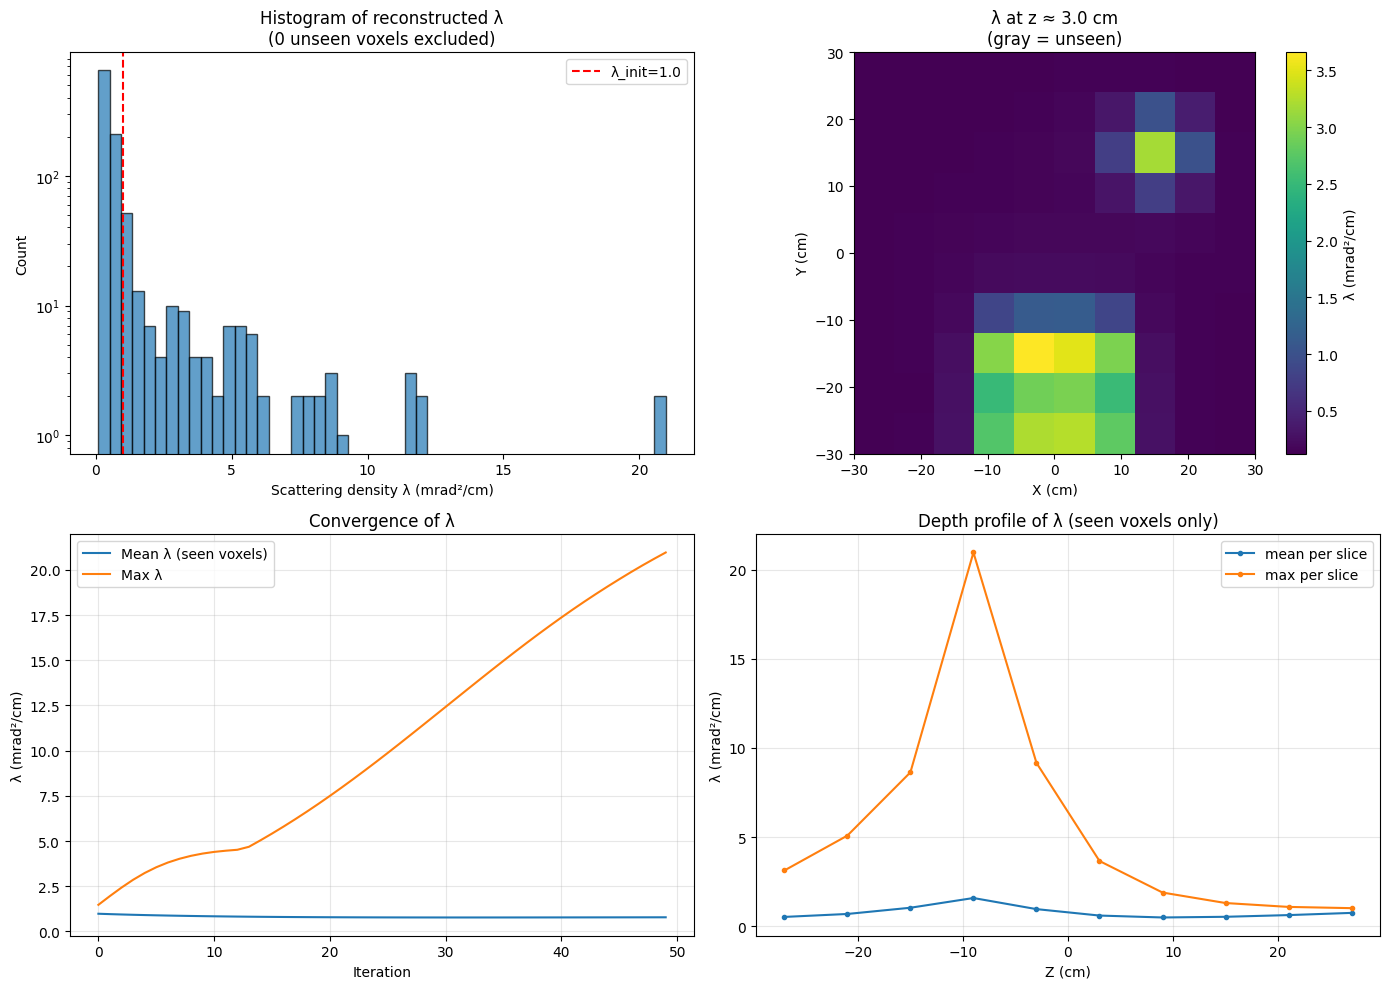


=== ML-EM Reconstruction Complete ===


In [71]:
# ============================================================
# Quick Visualization of Results
# ============================================================

print("\n--- Quick Visualization ---")

# Mask unseen voxels (λ = -1) for visualization
lambda_3d_masked = np.ma.masked_where(lambda_3d_save < 0, lambda_3d_save)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. λ histogram (seen voxels only, excludes -1 sentinel)
ax = axes[0, 0]
seen_vals = lambda_3d_save[lambda_3d_save >= 0]
n_unseen_display = np.sum(lambda_3d_save < 0)
if len(seen_vals) > 0:
    ax.hist(seen_vals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(LAMBDA_INIT, color='red', linestyle='--', label=f'λ_init={LAMBDA_INIT}')
    ax.set_xlabel('Scattering density λ (mrad²/cm)')
    ax.set_ylabel('Count')
    ax.set_title(f'Histogram of reconstructed λ\n({n_unseen_display} unseen voxels excluded)')
    ax.legend()
    ax.set_yscale('log')
else:
    ax.text(0.5, 0.5, 'No seen voxels', transform=ax.transAxes, ha='center')

# 2. Z-slice (middle layer) — unseen voxels shown as gray hatched
ax = axes[0, 1]
k_mid = N_Z // 2
slice_data = lambda_3d_save[:, :, k_mid]
slice_masked = np.ma.masked_where(slice_data < 0, slice_data)
im = ax.pcolormesh(
    np.linspace(X_MIN, X_MAX, N_X + 1),
    np.linspace(Y_MIN, Y_MAX, N_Y + 1),
    slice_masked.T,
    cmap='viridis', shading='auto')
# Overlay hatch for unseen voxels
unseen_slice = (slice_data < 0)
if np.any(unseen_slice):
    # Plot unseen voxels as a gray hatched overlay
    yy, xx = np.meshgrid(
        np.linspace(Y_MIN, Y_MAX, N_Y + 1),
        np.linspace(X_MIN, X_MAX, N_X + 1),
        indexing='ij')
    # Use pcolormesh with a neutral color and hatching for unseen areas
    unseen_data = np.where(unseen_slice, 1.0, np.nan)
    ax.pcolormesh(
        np.linspace(X_MIN, X_MAX, N_X + 1),
        np.linspace(Y_MIN, Y_MAX, N_Y + 1),
        unseen_data.T,
        cmap='Greys', shading='auto', alpha=0.3, vmin=0, vmax=1)
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_title(f'λ at z ≈ {Z_MIN + (k_mid + 0.5)*dz:.1f} cm\n(gray = unseen)')
ax.set_aspect('equal')
plt.colorbar(im, ax=ax, label='λ (mrad²/cm)')

# 3. Convergence plot (seen voxels only)
ax = axes[1, 0]
means = [lam[lam >= 0].mean() for lam in lambda_history]
maxs = [lam[lam >= 0].max() for lam in lambda_history]
ax.plot(means, label='Mean λ (seen voxels)')
ax.plot(maxs, label='Max λ')
ax.set_xlabel('Iteration')
ax.set_ylabel('λ (mrad²/cm)')
ax.set_title('Convergence of λ')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. λ per Z-slice depth profile (seen voxels only)
ax = axes[1, 1]
z_centers = np.linspace(Z_MIN + dz/2, Z_MAX - dz/2, N_Z)
for direction in ['mean', 'max']:
    if direction == 'mean':
        profile = np.array([
            lambda_3d_save[:, :, k][lambda_3d_save[:, :, k] >= 0].mean()
            if np.any(lambda_3d_save[:, :, k] >= 0) else np.nan
            for k in range(N_Z)])
    else:
        profile = np.array([
            lambda_3d_save[:, :, k][lambda_3d_save[:, :, k] >= 0].max()
            if np.any(lambda_3d_save[:, :, k] >= 0) else np.nan
            for k in range(N_Z)])
    ax.plot(z_centers, profile, 'o-', label=f'{direction} per slice', markersize=3)
ax.set_xlabel('Z (cm)')
ax.set_ylabel('λ (mrad²/cm)')
ax.set_title('Depth profile of λ (seen voxels only)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"ML_EM_diagnostic_{now.month:02d}-{now.day:02d}.png"),
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== ML-EM Reconstruction Complete ===")